<a href="https://colab.research.google.com/github/Manish281005/AI-Traffic/blob/main/ANPR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install torch torchvision torchaudio

In [ ]:
# Install roboflow
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 80.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 74.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [ ]:
from roboflow import Roboflow

# Download dataset
rf = Roboflow(api_key="oXHfvC7kbK4LQtcmDf1e")
project = rf.workspace("mk2005").project("indian-number-plate-q7hmg")
dataset = project.version(1).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Indian-number-plate-1 in yolov8:: 100%|██████████| 3378/3378 [00:00<00:00, 6288.07it/s]


In [ ]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 21.1 MB/s eta 0:00:00


In [ ]:
pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 963.8/963.8 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 13.2 MB/s eta 0:00:00


In [ ]:
pip install opencv-python

In [ ]:
pip install matplotlib

In [ ]:
pip install numpy

In [ ]:
from ultralytics import YOLO

# Load a pretrained YOLOv8 model
model = YOLO('yolov8n.pt')  # or yolov8s.pt for better accuracy

# Train the model
results = model.train(
    data=r"Indian-number-plate-1/data.yaml",
    epochs=5,
    imgsz=100,
    batch=8
)

Ultralytics 8.3.225 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Indian-number-plate-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=100, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose


image 1/1 /content/Indian-number-plate-1/test/images/WB27_jpg.rf.3e7c3afe36130a34448e397b1c3a3cd7.jpg: 128x128 1 IndianNumberPlate, 8.8ms
Speed: 0.4ms preprocess, 8.8ms inference, 4.1ms postprocess per image at shape (1, 3, 128, 128)


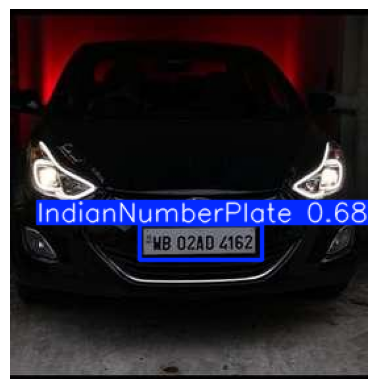

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Load trained model
model = YOLO(r"runs/detect/train2/weights/best.pt")

# Test image path (using an image from the downloaded dataset)
img_path = r"Indian-number-plate-1/test/images/WB27_jpg.rf.3e7c3afe36130a34448e397b1c3a3cd7.jpg"

# Perform detection
results = model(img_path)

# Display results
for r in results:
    boxes = r.boxes.xyxy
    plt.imshow(cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

In [ ]:
from ultralytics import YOLO

def initialize_model(model_path=r"runs/detect/train2/weights/best.pt"):
  model = YOLO(model_path)
  return model

In [ ]:
def preprocess_frame(frame):
  return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

In [ ]:
def perform_detection(model, frame):
  results = model(frame)
  return results[0].boxes.data.cpu().numpy()

In [ ]:
def draw_bounding_boxes(frame, detections, threshold=0.25):
  for detection in detections:
      x0, y0, x1, y1, confidence, class_id = detection
      if confidence > threshold:
          x0, y0, x1, y1 = map(int, [x0, y0, x1, y1])
          cv2.rectangle(frame, (x0, y0), (x1, y1), (0, 255, 0), 2)
          cv2.putText(frame, f"Conf: {confidence:.2f}", (x0, y0 - 10),
                      cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
  return frame

In [ ]:
def perform_ocr_on_box(frame, box):
  x0, y0, x1, y1 = map(int, box)
  cropped_image = frame[y0:y1, x0:x1]
  try:
      gray = cv2.cvtColor(cropped_image, cv2.COLOR_BGR2GRAY)
      gray = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                    cv2.THRESH_BINARY, 11, 2)
      config = r'--oem 3 --psm 7 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'
      text = pytesseract.image_to_string(gray, config=config).strip()
  except Exception as e:
      text = f"Error: {e}"
  return text

In [ ]:

def main_realtime(model_path="yolov8n.pt"):
    model = initialize_model(model_path)
    cap = cv2.VideoCapture(0)  # Open default webcam

    if not cap.isOpened():
        print("Error: Unable to access the camera.")
        return

    while True:
        ret, frame = cap.read()
        if not ret:
            print("Error: Unable to read frame from camera.")
            break

        rgb_frame = preprocess_frame(frame)
        detections = perform_detection(model, rgb_frame)
        frame_with_boxes = draw_bounding_boxes(frame, detections)

        for detection in detections:
            x0, y0, x1, y1, confidence, class_id = detection
            if confidence > 0.25:  # Ensure only confident detections are processed
                number_plate_text = perform_ocr_on_box(frame, (x0, y0, x1, y1))
                cv2.putText(frame_with_boxes, f"Plate: {number_plate_text}", (int(x0), int(y0) - 30),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)

        cv2.imshow('ANPR Realtime', frame_with_boxes)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

if __name__ == "__main__":
    main_realtime()

Error: Unable to access the camera.


In [64]:
import cv2
from google.colab import output
import ipywidgets as widgets
from IPython.display import display, Javascript, clear_output
from base64 import b64decode
import numpy as np
import io
from PIL import Image
from ultralytics import YOLO
import os
import datetime

# Install Tesseract if not already installed
!sudo apt update
!sudo apt install tesseract-ocr
# Import the Tesseract OCR library
import pytesseract


# Modify initialize_model to load the best trained model
def initialize_model(model_path=r"runs/detect/train2/weights/best.pt"):
  model = YOLO(model_path)
  return model

def preprocess_frame(frame):
  return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

def perform_detection(model, frame):
  results = model(frame)
  # Return detections with class IDs
  if results and results[0].boxes:
    return results[0].boxes.data.cpu().numpy()
  else:
    return []


def draw_bounding_boxes(frame, detections, threshold=0.25):
  frame_copy = frame.copy() # Draw on a copy to avoid modifying the original frame
  for detection in detections:
      x0, y0, x1, y1, confidence, class_id = detection
      if confidence > threshold:
          x0, y0, x1, y1 = map(int, [x0, y0, x1, y1])
          # Draw only if the class ID is 0 (assuming 'IndianNumberPlate' is class 0 based on training)
          if int(class_id) == 0:
              cv2.rectangle(frame_copy, (x0, y0), (int(x1), int(y1)), (0, 255, 0), 2)
              cv2.putText(frame_copy, f"Conf: {confidence:.2f}", (int(x0), int(y0) - 10),
                          cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
  return frame_copy


# Modified function to extract text using Tesseract
def extract_text_tesseract(image):
    print("Attempting OCR with Tesseract...") # Debug print
    try:
        # Convert the OpenCV image (numpy array) to a PIL Image
        pil_image = Image.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        # Use Tesseract to read text from the image
        config = r'--oem 3 --psm 7 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'
        text = pytesseract.image_to_string(pil_image, config=config).strip()
        print(f"Extracted text with Tesseract: {text}") # Debug print
        return text if text else "None" # Return "None" if no text is detected
    except Exception as e:
        print(f"Tesseract OCR Error: {e}") # Debug print
        return f"Error: {e}"

# Helper function to capture image from Colab webcam
def capture_frame(quality=0.8):
  js_code = '''
    (async function capture() { // Wrap in an IIFE
      const div = document.createElement('div');
      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      return canvas.toDataURL('image/jpeg', %f);
    })(); // Execute the IIFE immediately
  ''' % (quality)
  data = output.eval_js(js_code) # Pass the JS code as a string to eval_js
  return data

# Directory to save results
save_dir = "number_plate_results"
os.makedirs(save_dir, exist_ok=True)

# Function to process a single frame and save results
def process_and_save_frame(model):
    print("Capturing single frame from webcam...")
    data = capture_frame()
    if not data:
        print("Error capturing frame from webcam.")
        return

    binary_data = b64decode(data.split(',')[1])
    np_arr = np.frombuffer(binary_data, np.uint8)
    frame = cv2.imdecode(np_arr, cv2.IMREAD_COLOR)

    if frame is None:
        print("Error decoding frame.")
        return

    rgb_frame = preprocess_frame(frame)
    detections = perform_detection(model, rgb_frame)

    frame_with_boxes = frame.copy()
    extracted_texts = []

    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

    for i, detection in enumerate(detections):
        x0, y0, x1, y1, confidence, class_id = detection
        if confidence > 0.25 and int(class_id) == 0:
            cv2.rectangle(frame_with_boxes, (int(x0), int(y0)), (int(x1), int(y1)), (0, 255, 0), 2)
            cv2.putText(frame_with_boxes, f"Conf: {confidence:.2f}", (int(x0), int(y0) - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)

            cropped_image = frame[int(y0):int(y1), int(x0):int(x1)]

            if cropped_image.shape[0] > 0 and cropped_image.shape[1] > 0:
                number_plate_text = extract_text_tesseract(cropped_image)
                extracted_texts.append(number_plate_text)
                cv2.putText(frame_with_boxes, f"Plate: {number_plate_text}", (int(x0), int(y0) - 30),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)

                # Save the cropped number plate image
                img_filename = os.path.join(save_dir, f"plate_{timestamp}_{i}.jpg")
                cv2.imwrite(img_filename, cropped_image)
                print(f"Saved detected plate image: {img_filename}")

                # Save the extracted text to a file
                text_filename = os.path.join(save_dir, f"plate_{timestamp}_{i}.txt")
                with open(text_filename, "w") as f:
                    f.write(number_plate_text)
                print(f"Saved extracted text: {text_filename}")


            else:
                print("Warning: Cropped image is empty for detection.")
                extracted_texts.append("N/A")

    print(f"Extracted texts for this frame: {', '.join(extracted_texts)}")

    # Display the processed frame
    if frame_with_boxes is not None:
        print("Displaying processed frame:")
        _, jpeg = cv2.imencode('.jpg', frame_with_boxes)
        display(Image.open(io.BytesIO(jpeg.tobytes())))
    else:
        print("No frame to display after processing.")


# Initialize the model once
yolo_model = initialize_model()

# Create a button widget
capture_button = widgets.Button(description="Capture and Process Frame")
output_widget = widgets.Output()

def on_button_clicked(b):
    with output_widget:
        clear_output(wait=True) # Clear previous output
        process_and_save_frame(yolo_model)

capture_button.on_click(on_button_clicked)

# Display the button and output widget
display(capture_button, output_widget)

Hit:1 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
44 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Skipping acquire of configured file 'main/source/Sources' as re

Button(description='Capture and Process Frame', style=ButtonStyle())

Output()

In [65]:
import cv2
from google.colab import output
import ipywidgets as widgets
from IPython.display import display, Javascript, clear_output
from base64 import b64decode
import numpy as np
import io
from PIL import Image
from ultralytics import YOLO
import os
import datetime

# Install Tesseract if not already installed
!sudo apt update
!sudo apt install tesseract-ocr
# Import the Tesseract OCR library
import pytesseract


# Modify initialize_model to load the best trained model
def initialize_model(model_path=r"runs/detect/train2/weights/best.pt"):
  model = YOLO(model_path)
  return model

def preprocess_frame(frame):
  return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

def perform_detection(model, frame):
  results = model(frame)
  # Return detections with class IDs
  if results and results[0].boxes:
    return results[0].boxes.data.cpu().numpy()
  else:
    return []


def draw_bounding_boxes(frame, detections, threshold=0.25):
  frame_copy = frame.copy() # Draw on a copy to avoid modifying the original frame
  for detection in detections:
      x0, y0, x1, y1, confidence, class_id = detection
      if confidence > threshold:
          x0, y0, x1, y1 = map(int, [x0, y0, x1, y1])
          # Draw only if the class ID is 0 (assuming 'IndianNumberPlate' is class 0 based on training)
          if int(class_id) == 0:
              cv2.rectangle(frame_copy, (x0, y0), (int(x1), int(y1)), (0, 255, 0), 2)
              cv2.putText(frame_copy, f"Conf: {confidence:.2f}", (int(x0), int(y0) - 10),
                          cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
  return frame_copy


# Modified function to extract text using Tesseract
def extract_text_tesseract(image):
    print("Attempting OCR with Tesseract...") # Debug print
    try:
        # Convert the OpenCV image (numpy array) to a PIL Image
        pil_image = Image.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        # Use Tesseract to read text from the image
        config = r'--oem 3 --psm 7 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'
        text = pytesseract.image_to_string(pil_image, config=config).strip()
        print(f"Extracted text with Tesseract: {text}") # Debug print
        return text if text else "None" # Return "None" if no text is detected
    except Exception as e:
        print(f"Tesseract OCR Error: {e}") # Debug print
        return f"Error: {e}"

# Helper function to capture image from Colab webcam
def capture_frame(quality=0.8):
  js_code = '''
    (async function capture() { // Wrap in an IIFE
      const div = document.createElement('div');
      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      return canvas.toDataURL('image/jpeg', %f);
    })(); // Execute the IIFE immediately
  ''' % (quality)
  data = output.eval_js(js_code) # Pass the JS code as a string to eval_js
  return data

# Directory to save results
save_dir = "number_plate_results"
os.makedirs(save_dir, exist_ok=True)

# Function to process a single frame and save results
def process_and_save_frame(model):
    print("Capturing single frame from webcam...")
    data = capture_frame()
    if not data:
        print("Error capturing frame from webcam.")
        return

    binary_data = b64decode(data.split(',')[1])
    np_arr = np.frombuffer(binary_data, np.uint8)
    frame = cv2.imdecode(np_arr, cv2.IMREAD_COLOR)

    if frame is None:
        print("Error decoding frame.")
        return

    rgb_frame = preprocess_frame(frame)
    detections = perform_detection(model, rgb_frame)

    frame_with_boxes = frame.copy()
    extracted_texts = []

    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

    for i, detection in enumerate(detections):
        x0, y0, x1, y1, confidence, class_id = detection
        if confidence > 0.25 and int(class_id) == 0:
            cv2.rectangle(frame_with_boxes, (int(x0), int(y0)), (int(x1), int(y1)), (0, 255, 0), 2)
            cv2.putText(frame_with_boxes, f"Conf: {confidence:.2f}", (int(x0), int(y0) - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)

            cropped_image = frame[int(y0):int(y1), int(x0):int(x1)]

            if cropped_image.shape[0] > 0 and cropped_image.shape[1] > 0:
                number_plate_text = extract_text_tesseract(cropped_image)
                extracted_texts.append(number_plate_text)
                cv2.putText(frame_with_boxes, f"Plate: {number_plate_text}", (int(x0), int(y0) - 30),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)

                # Save the cropped number plate image
                img_filename = os.path.join(save_dir, f"plate_{timestamp}_{i}.jpg")
                cv2.imwrite(img_filename, cropped_image)
                print(f"Saved detected plate image: {img_filename}")

                # Save the extracted text to a file
                text_filename = os.path.join(save_dir, f"plate_{timestamp}_{i}.txt")
                with open(text_filename, "w") as f:
                    f.write(number_plate_text)
                print(f"Saved extracted text: {text_filename}")


            else:
                print("Warning: Cropped image is empty for detection.")
                extracted_texts.append("N/A")

    print(f"Extracted texts for this frame: {', '.join(extracted_texts)}")

    # Display the processed frame
    if frame_with_boxes is not None:
        print("Displaying processed frame:")
        _, jpeg = cv2.imencode('.jpg', frame_with_boxes)
        display(Image.open(io.BytesIO(jpeg.tobytes())))
    else:
        print("No frame to display after processing.")


# Initialize the model once
yolo_model = initialize_model()

# Create a button widget
capture_button = widgets.Button(description="Capture and Process Frame")
output_widget = widgets.Output()

def on_button_clicked(b):
    with output_widget:
        clear_output(wait=True) # Clear previous output
        process_and_save_frame(yolo_model)

capture_button.on_click(on_button_clicked)

# Display the button and output widget
display(capture_button, output_widget)

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:4 https://cli.github.com/packages stable InRelease
Hit:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Hit:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
44 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Skipping acquire of configured file 'main/source/Sources' as re

Button(description='Capture and Process Frame', style=ButtonStyle())

Output()